# Computer Vision Basics Recap

This notebook recaps fundamental CV concepts for intermediate learners. We'll cover image loading, color spaces, filtering, and transformations using OpenCV and NumPy.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

image = data.astronaut()  # Example image from skimage
print('Image loaded successfully. Shape:', image.shape)

Image loaded successfully. Shape: (512, 512, 3)


**Explanation:** We import necessary libraries (OpenCV for CV tasks, NumPy for arrays, Matplotlib for plotting, skimage for data). The `data.astronaut()` function from skimage loads a built-in example image as a NumPy array in RGB format. This provides a sample image without needing external files. The shape shows height, width, and channels (e.g., 3 for RGB).

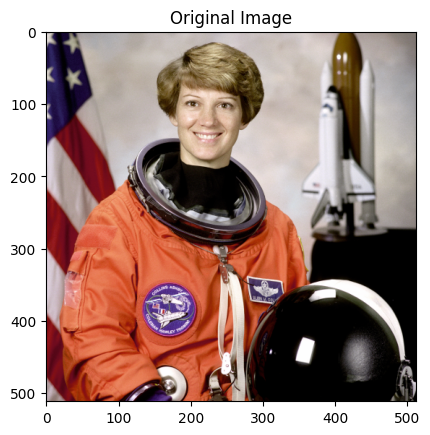

Image is in RGB format.


In [6]:
# Display
plt.imshow(image)
plt.title('Original Image')
plt.show()
print('Image is in RGB format.')

**Explanation:** Since skimage loads images in RGB format by default, no color conversion is needed. `plt.imshow()` displays the image directly, and `plt.show()` renders it. This ensures accurate visualization.

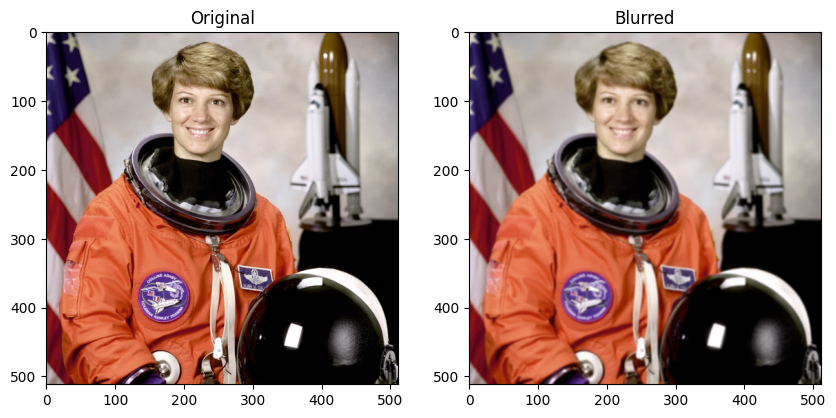

In [7]:
# Apply Gaussian blur
blurred = cv2.GaussianBlur(image, (5, 5), 0)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.title('Blurred')
plt.show()

**Explanation:** `cv2.GaussianBlur()` applies a Gaussian filter to reduce noise and smooth the image. The kernel size (5,5) and sigma (0) control the blur intensity. We compare original and blurred images side-by-side for visual impact.

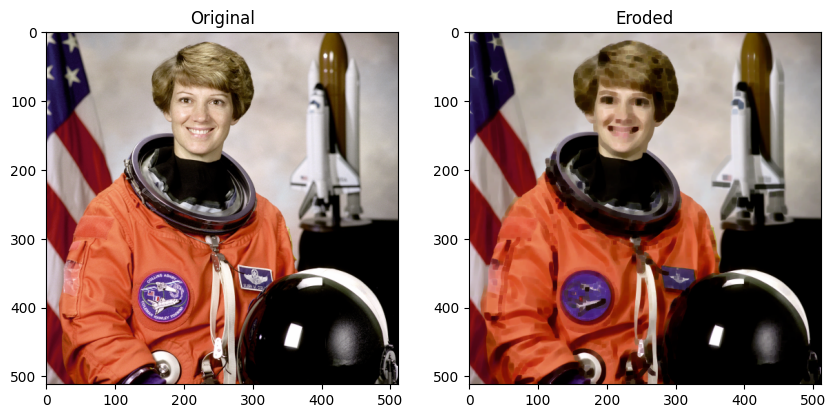

In [8]:
# Morphological operations (e.g., erosion)
kernel = np.ones((5,5), np.uint8)
eroded = cv2.erode(image, kernel, iterations=1)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(eroded)
plt.title('Eroded')
plt.show()

**Detailed Explanation:**

Morphological operations are image processing techniques that analyze and manipulate the shape and structure of objects in an image. They are based on set theory and use a structuring element (kernel) to probe the image.

- **What is Erosion?** Erosion shrinks or thins objects in a binary or grayscale image. It removes pixels from the boundaries of objects, which can help eliminate small noise, separate connected objects, or find the skeleton of shapes.
- **How it Works:** For each pixel in the image, the erosion operation checks if the structuring element fits entirely within the foreground (white) pixels. If not, the pixel is set to background (black). This effectively erodes the edges.
- **Kernel Creation:** We use `np.ones((5,5), np.uint8)` to create a 5x5 square kernel filled with ones. This is a simple structuring element; other shapes like circles can be used for different effects.
- **Parameters:**
  - `kernel`: The structuring element (5x5 square here).
  - `iterations=1`: Number of times to apply erosion (more iterations = more erosion).
- **Applications:** Noise removal, object separation, edge detection, and preprocessing for other operations.
- **Comparison to Blurring:** Unlike Gaussian blur (which smooths by averaging), erosion is a morphological operation that preserves shape while altering size, making it ideal for binary images or shape analysis.

This demonstrates advanced filtering techniques beyond simple convolution-based blurring, highlighting OpenCV's morphological tools.

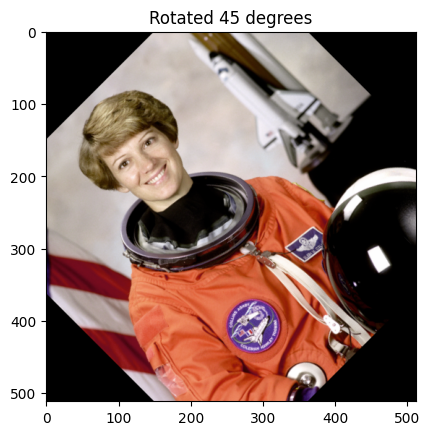

In [9]:
# Basic transformation: rotation
(h, w) = image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(image, M, (w, h))
plt.imshow(rotated)
plt.title('Rotated 45 degrees')
plt.show()

**Explanation:** Transformations like rotation use affine matrices. `cv2.getRotationMatrix2D()` creates the matrix for 45-degree rotation around the center. `cv2.warpAffine()` applies it, resizing if needed. This shows geometric manipulations.

## Summary
This notebook reviewed key CV basics: loading images, color conversions, filtering (blur and morphology), and transformations. Experiment by changing parameters (e.g., kernel sizes, angles) to see effects. Next, explore object detection in phase 2.